In [48]:
import pandas as pd
%matplotlib inline

df_red = pd.read_csv("E://Datasets//wine_quality//winequality-red.csv")
df_white = pd.read_csv("E://Datasets//wine_quality//winequality-white.csv")


In [49]:
df_red = df_red.drop("quality", axis=1)
df_white = df_white.drop("quality", axis=1)
df_red["target"] = 1
df_white["target"] = 0

In [50]:
df = pd.concat([df_red, df_white], axis=0)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  target                6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 659.9 KB


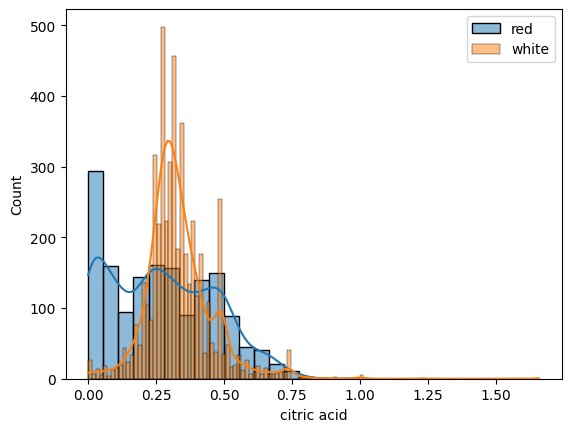

In [52]:
#Compare citrici acid for red wine and white wine using seaborn
import seaborn as sns
import matplotlib.pyplot as plt
#Draw bell curve
sns.histplot(df[df["target"] == 1]["citric acid"], label="red", kde=True)
sns.histplot(df[df["target"] == 0]["citric acid"], label="white", kde=True)
plt.legend()

In [53]:
#function to plot histogram
def plot_hist(df, feature):
    red = df[df["target"] == 1][feature]
    white = df[df["target"] == 0][feature]
    sns.histplot(red, label="red", kde=True)
    sns.histplot(white, label="white", kde=True)
    plt.legend()
    plt.xlabel(feature)
    plt.show()
    return

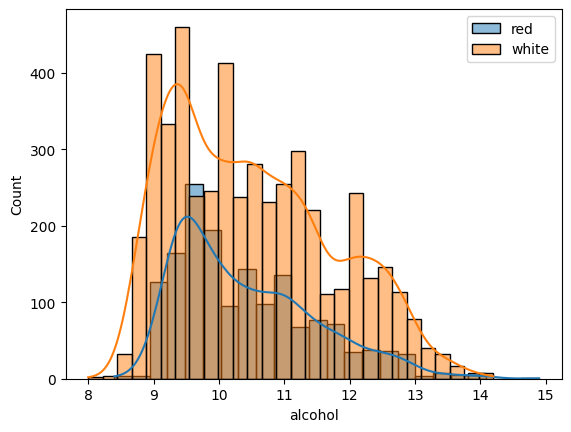

In [54]:
plot_hist(df, "alcohol")

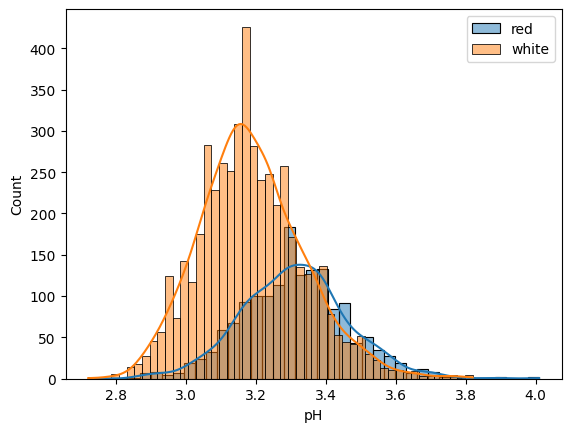

In [55]:
plot_hist(df, "pH")
#White wines are more acidic

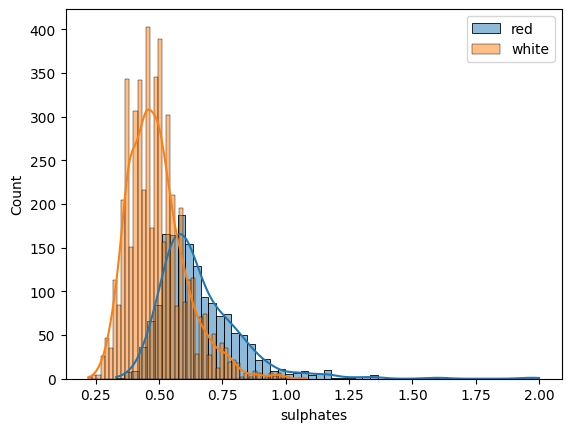

In [56]:
plot_hist(df, "sulphates")

In [57]:
#Mean value of citric acid
df.groupby("target")["citric acid"].mean()
#White wine has more citric acid than red hence they have less pH

target
0    0.334192
1    0.270976
Name: citric acid, dtype: float64

In [58]:
df.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
fixed acidity,1.000000,0.219008,0.324436,-0.111981,0.298195,-0.282735,-0.329054,0.458910,-0.252700,0.299568,-0.095452,0.486740
volatile acidity,0.219008,1.000000,-0.377981,-0.196011,0.377124,-0.352557,-0.414476,0.271296,0.261454,0.225984,-0.037640,0.653036
citric acid,0.324436,-0.377981,1.000000,0.142451,0.038998,0.133126,0.195242,0.096154,-0.329808,0.056197,-0.010493,-0.187397
residual sugar,-0.111981,-0.196011,0.142451,1.000000,-0.128940,0.402871,0.495482,0.552517,-0.267320,-0.185927,-0.359415,-0.348821
chlorides,0.298195,0.377124,0.038998,-0.128940,1.000000,-0.195045,-0.279630,0.362615,0.044708,0.395593,-0.256916,0.512678
free sulfur dioxide,-0.282735,-0.352557,0.133126,0.402871,-0.195045,1.000000,0.720934,0.025717,-0.145854,-0.188457,-0.179838,-0.471644
total sulfur dioxide,-0.329054,-0.414476,0.195242,0.495482,-0.279630,0.720934,1.000000,0.032395,-0.238413,-0.275727,-0.265740,-0.700357
density,0.458910,0.271296,0.096154,0.552517,0.362615,0.025717,0.032395,1.000000,0.011686,0.259478,-0.686745,0.390645
pH,-0.252700,0.261454,-0.329808,-0.267320,0.044708,-0.145854,-0.238413,0.011686,1.000000,0.192123,0.121248,0.329129
sulphates,0.299568,0.225984,0.056197,-0.185927,0.395593,-0.188457,-0.275727,0.259478,0.192123,1.000000,-0.003029,0.487218


In [59]:
from sklearn.model_selection import train_test_split
X = df[df.columns[:-1]]
y = df["target"]


In [60]:
#Use stratified sampling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True)

In [61]:
y_train.value_counts()

target
0    3918
1    1279
Name: count, dtype: int64

In [62]:
y_test.value_counts()

target
0    980
1    320
Name: count, dtype: int64

In [63]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf = clf.fit(X_train, y_train)



e:\Miniconda\envs\d2l\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Recall: Ability of a model to correctly classify a positive instance.
Recall = TP/(TP+FN)

Precision: Proportion of all the model's positive classifications that are actually positive
Precision = TP/(TP+FP)

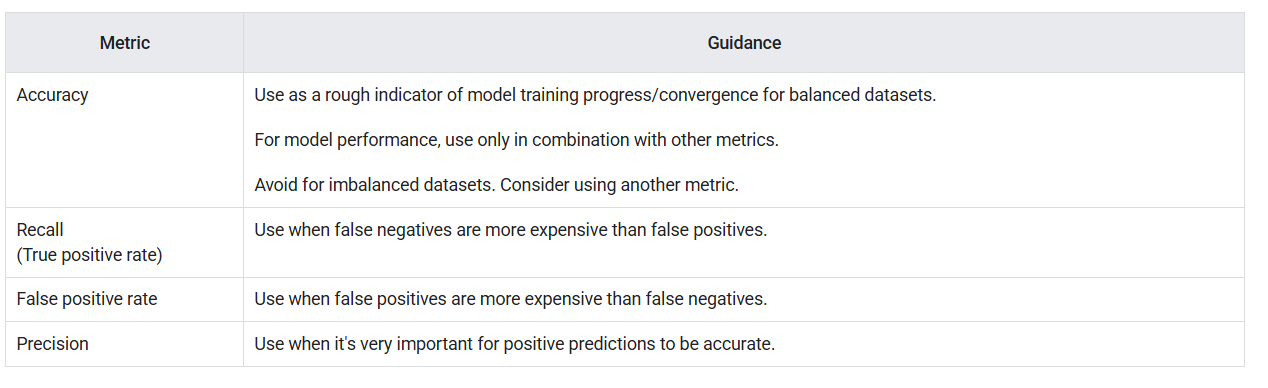

In [64]:
from sklearn.metrics import recall_score, precision_score
y_pred = clf.predict(X_test)
precision_score(y_test, y_pred)


0.9748427672955975

In [65]:
recall_score(y_test, y_pred)

0.96875